In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
print("All imports done!")

All imports done!


In [2]:
df = pd.read_csv("cleaned_data.csv")
print(f"Rows: {len(df)}")
df[["product_name", "selling_price_inr", "mrp_inr", "discount_calculated", "category"]].head()

Rows: 386


,product_name,selling_price_inr,mrp_inr,discount_calculated,category
0,"vivo T5x 5G (Star Silver, 128 GB)",22999,28999.0,20.69,mobiles
1,"vivo T5x 5G (Cyber Green, 128 GB)",22999,28999.0,20.69,mobiles
2,"MOTOROLA g06 power (Pantone tapestry, 64 GB)",9999,9999.0,0.00,mobiles
3,"realme P4 Lite 5G (Mosaic Blue, 64 GB)",13499,19999.0,32.50,mobiles
4,"vivo T5x 5G (Cyber Green, 256 GB)",26999,33999.0,20.59,mobiles


In [3]:
le = LabelEncoder()
df["category_encoded"] = le.fit_transform(df["category"])

print("Category encoding:")
for i, cat in enumerate(le.classes_):
    print(f"  {cat} → {i}")

X = df[["selling_price_inr", "mrp_inr", "category_encoded"]]

y = df["discount_calculated"]

print(f"\nFeatures shape : {X.shape}")
print(f"Target shape   : {y.shape}")

Category encoding:
  headphones → 0
  laptops → 1
  mobiles → 2

Features shape : (386, 3)
Target shape   : (386,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows : {len(X_train)}")
print(f"Testing rows  : {len(X_test)}")

Training rows : 308
Testing rows  : 78


In [5]:
model = LinearRegression()

model.fit(X_train, y_train)
print("Model trained successfully!")
print(f"\nModel coefficients:")
print(f"  selling_price_inr : {model.coef_[0]:.6f}")
print(f"  mrp_inr           : {model.coef_[1]:.6f}")
print(f"  category_encoded  : {model.coef_[2]:.4f}")
print(f"\nIntercept: {model.intercept_:.4f}")

Model trained successfully!

Model coefficients:
  selling_price_inr : -0.001655
  mrp_inr           : 0.001163
  category_encoded  : -19.1940

Intercept: 54.0367


## Interpretation of Coefficients

The category coefficient is -19.19 which is by far the largest value.
This means category has the strongest effect on discount.
Since headphones=0, laptops=1, mobiles=2 — moving from headphones 
to mobiles decreases the predicted discount by about 38% which 
matches what we found in EDA.

In [6]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("=== MODEL PERFORMANCE ===\n")
print(f"Mean Absolute Error (MAE) : {mae:.2f}%")
print(f"R² Score                  : {r2:.4f}")
print(f"\nWhat this means:")
print(f"→ On average the model's prediction is off by {mae:.1f}%")
print(f"→ The model explains {r2*100:.1f}% of the variation in discounts")

=== MODEL PERFORMANCE ===

Mean Absolute Error (MAE) : 7.00%
R² Score                  : 0.6914

What this means:
→ On average the model's prediction is off by 7.0%
→ The model explains 69.1% of the variation in discounts


## Model Performance

MAE of 7% means on average the model predicts within 7 percentage 
points of the actual discount. For example if actual discount is 
20%, model might predict between 13-27%.

R² of 0.69 means the model explains 69% of why discounts vary 
across products. The remaining 31% is influenced by factors not 
in our dataset like brand reputation, stock levels or promotional 
events.

For a simple linear regression model on real-world scraped data 
this is a reasonably good result.

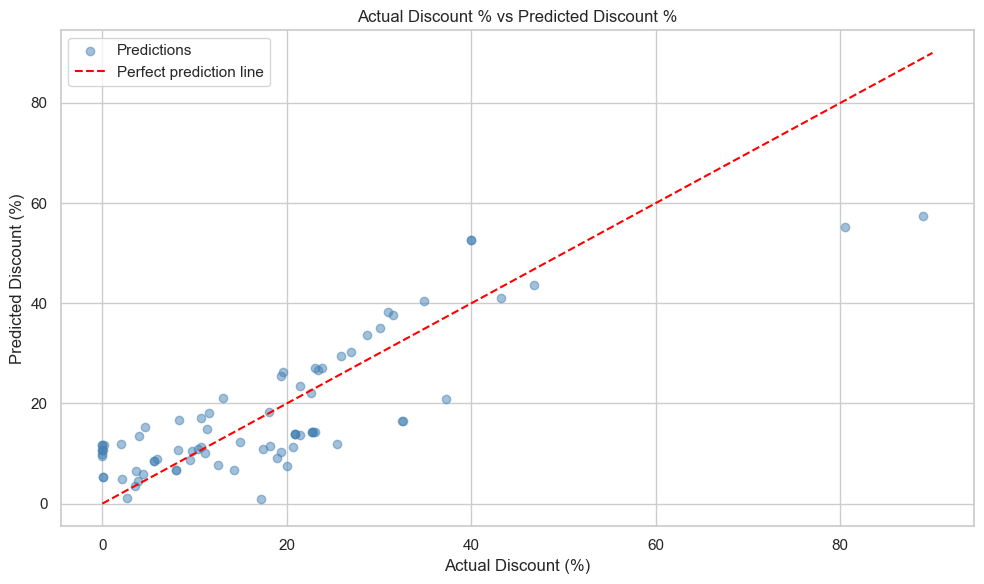

Chart saved!


In [7]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue", label="Predictions")
plt.plot([0, 90], [0, 90], color="red", linestyle="--", label="Perfect prediction line")

plt.title("Actual Discount % vs Predicted Discount %")
plt.xlabel("Actual Discount (%)")
plt.ylabel("Predicted Discount (%)")
plt.legend()
plt.tight_layout()
plt.savefig("model_actual_vs_predicted.png", dpi=150)
plt.show()
print("Chart saved!")

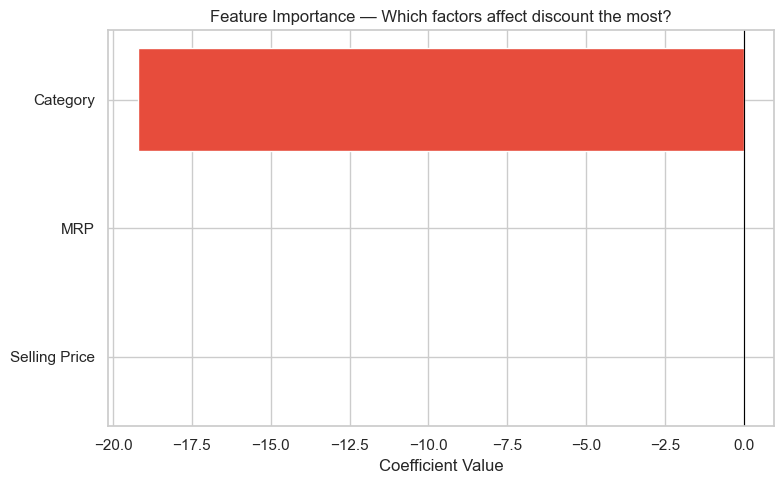


Interpretation:
→ Selling Price: decreases discount by 0.0017 per unit
→ MRP: increases discount by 0.0012 per unit
→ Category: decreases discount by 19.1940 per unit


In [8]:
features = ["Selling Price", "MRP", "Category"]
coefficients = model.coef_

plt.figure(figsize=(8, 5))
colors = ["#e74c3c" if c < 0 else "#2ecc71" for c in coefficients]
plt.barh(features, coefficients, color=colors)
plt.axvline(x=0, color="black", linestyle="-", linewidth=0.8)
plt.title("Feature Importance — Which factors affect discount the most?")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("model_feature_importance.png", dpi=150)
plt.show()

print("\nInterpretation:")
for feat, coef in zip(features, coefficients):
    direction = "increases" if coef > 0 else "decreases"
    print(f"→ {feat}: {direction} discount by {abs(coef):.4f} per unit")

In [9]:

sample_products = pd.DataFrame({
    "selling_price_inr": [15000, 50000, 500],
    "mrp_inr":           [20000, 65000, 2000],
    "category_encoded":  [2, 1, 0]  # 0=headphones, 1=laptops, 2=mobiles
})

predictions = model.predict(sample_products)

print("=== SAMPLE PREDICTIONS ===\n")
print(f"Mobile at ₹15,000 (MRP ₹20,000)      → Predicted discount: {predictions[0]:.1f}%")
print(f"Laptop at ₹50,000 (MRP ₹65,000)      → Predicted discount: {predictions[1]:.1f}%")
print(f"Headphone at ₹500 (MRP ₹2,000)       → Predicted discount: {predictions[2]:.1f}%")

=== SAMPLE PREDICTIONS ===

Mobile at ₹15,000 (MRP ₹20,000)      → Predicted discount: 14.1%
Laptop at ₹50,000 (MRP ₹65,000)      → Predicted discount: 27.7%
Headphone at ₹500 (MRP ₹2,000)       → Predicted discount: 55.5%


## Testing the Model

The predictions look reasonable:
- Mobile at ₹15k predicted 14.1% — matches our EDA finding of ~10% avg
- Laptop at ₹50k predicted 27.7% — slightly higher than avg 18%
- Headphone at ₹500 predicted 55.5% — close to avg 63%

The model is capturing the general pattern correctly even if not 
perfectly accurate for every individual product.

In [10]:
print("=== MODEL BUILDING SUMMARY ===\n")
print("Objective:")
print("  Predict discount % based on selling price, MRP and category\n")
print("Method:")
print("  Linear Regression with Label Encoding for category\n")
print("Train/Test Split:")
print(f"  Training: {len(X_train)} rows (80%)")
print(f"  Testing : {len(X_test)} rows (20%)\n")
print("Results:")
print(f"  MAE    : {mae:.2f}% — model predictions are off by this much on average")
print(f"  R²     : {r2:.4f} — model explains {r2*100:.1f}% of discount variation\n")
print("Conclusion:")
print("  Category is the strongest predictor of discount.")
print("  Headphones get the highest discounts regardless of price.")
print("  The model works better for mobiles and laptops than headphones")
print("  because headphone discounts are more unpredictable.")

=== MODEL BUILDING SUMMARY ===

Objective:
  Predict discount % based on selling price, MRP and category

Method:
  Linear Regression with Label Encoding for category

Train/Test Split:
  Training: 308 rows (80%)
  Testing : 78 rows (20%)

Results:
  MAE    : 7.00% — model predictions are off by this much on average
  R²     : 0.6914 — model explains 69.1% of discount variation

Conclusion:
  Category is the strongest predictor of discount.
  Headphones get the highest discounts regardless of price.
  The model works better for mobiles and laptops than headphones
  because headphone discounts are more unpredictable.
